# 06 — Delta-hedging : P&L, fréquence de rebalancement, coûts de transaction et stress tests

**Question.** Quelle est la performance d'une stratégie de delta-hedging selon la fréquence de rebalancement, les coûts de transaction, l'erreur sur la volatilité et le modèle du sous-jacent ?

**Position étudiée** : un market-maker **vend une option** (il encaisse la prime), puis se couvre en détenant $\Delta$ actions, financées au taux sans risque, rebalancées à intervalles discrets. À chaque pas :

$$\Pi_t = \underbrace{\text{Cash}_t}_{\text{prime} - \text{achats d'actions} - \text{frais} + \text{intérêts} + \text{dividendes}} + \Delta_t S_t - V_t, \qquad \text{P\&L}_T = \Pi_T$$

En temps continu et si la vol réalisée égale la vol de pricing, $\Pi_T = 0$. En pratique trois sources d'erreur apparaissent :
1. **discrétisation** : entre deux rebalancements, le gamma fait dériver le delta ;
2. **erreur de volatilité** : $\text{P\&L} \approx \tfrac12 \int_0^T \Gamma_t S_t^2 \big(\sigma_{imp}^2 - \sigma_{réal}^2\big)\,dt$ pour le vendeur ;
3. **coûts de transaction**, qui croissent avec la fréquence.

Modules : `src/hedging.py` (boucle détaillée + version vectorisée identique, testée dans `tests/test_hedging.py`) et `src/backtest.py` (données réelles).

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
warnings.filterwarnings("ignore", category=RuntimeWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotting import set_style, savefig, save_table, PALETTE

set_style()
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 160)
%matplotlib inline
import json
from black_scholes import black_scholes_price as bs
from greeks import delta, gamma, vega
from hedging import simulate_gbm_paths, delta_hedging, delta_hedging_vectorized
from heston import simulate_heston_paths
from heston_pricing import heston_call_price
from implied_vol import implied_volatility
from backtest import historical_backtest
from market_data import get_option_chain, get_underlying_history
from plotting import RES_DIR

def stats(pnl, premium=None):
    q = np.percentile(pnl, [1, 5, 50, 95])
    out = {"Moyenne": pnl.mean(), "Écart-type": pnl.std(), "Q1%": q[0], "Q5%": q[1], "Médiane": q[2], "Q95%": q[3],
           "CVaR 5%": pnl[pnl <= q[1]].mean(), "% P&L < 0": 100 * (pnl < 0).mean()}
    if premium is not None:
        out["Écart-type / prime (%)"] = 100 * pnl.std() / premium
    return out

## 1. Mécanique sur une trajectoire

Call ATM vendu, S = K = 100, T = 3 mois, σ = 20 %, r = 2 %, q = 1,5 %, rebalancement quotidien, 5 bp de frais.

,jour,spot,time_to_maturity,option_price,delta,stock_shares,cash,transaction_costs,portfolio_value,cumulative_pnl
0,0,100.0000,0.2500,4.0329,0.5230,0.5230,-48.2885,0.0261,-0.0261,-0.0261
1,1,102.1466,0.2460,5.2135,0.6065,0.6065,-56.8298,0.0043,-0.0892,-0.0892
2,2,101.5427,0.2421,4.8217,0.5838,0.5838,-54.5250,0.0012,-0.0656,-0.0656
30,30,97.1029,0.1310,1.6462,0.3584,0.3584,-33.2611,0.0014,-0.1099,-0.1099
61,61,96.1696,0.0079,0.0088,0.0146,0.0146,-1.6174,0.0022,-0.2228,-0.2228
62,62,93.8817,0.0040,0.0000,0.0000,0.0000,-0.2482,0.0007,-0.2481,-0.2481
63,63,93.7584,0.0000,0.0000,0.0000,0.0000,-0.2482,0.0000,-0.2482,-0.2482


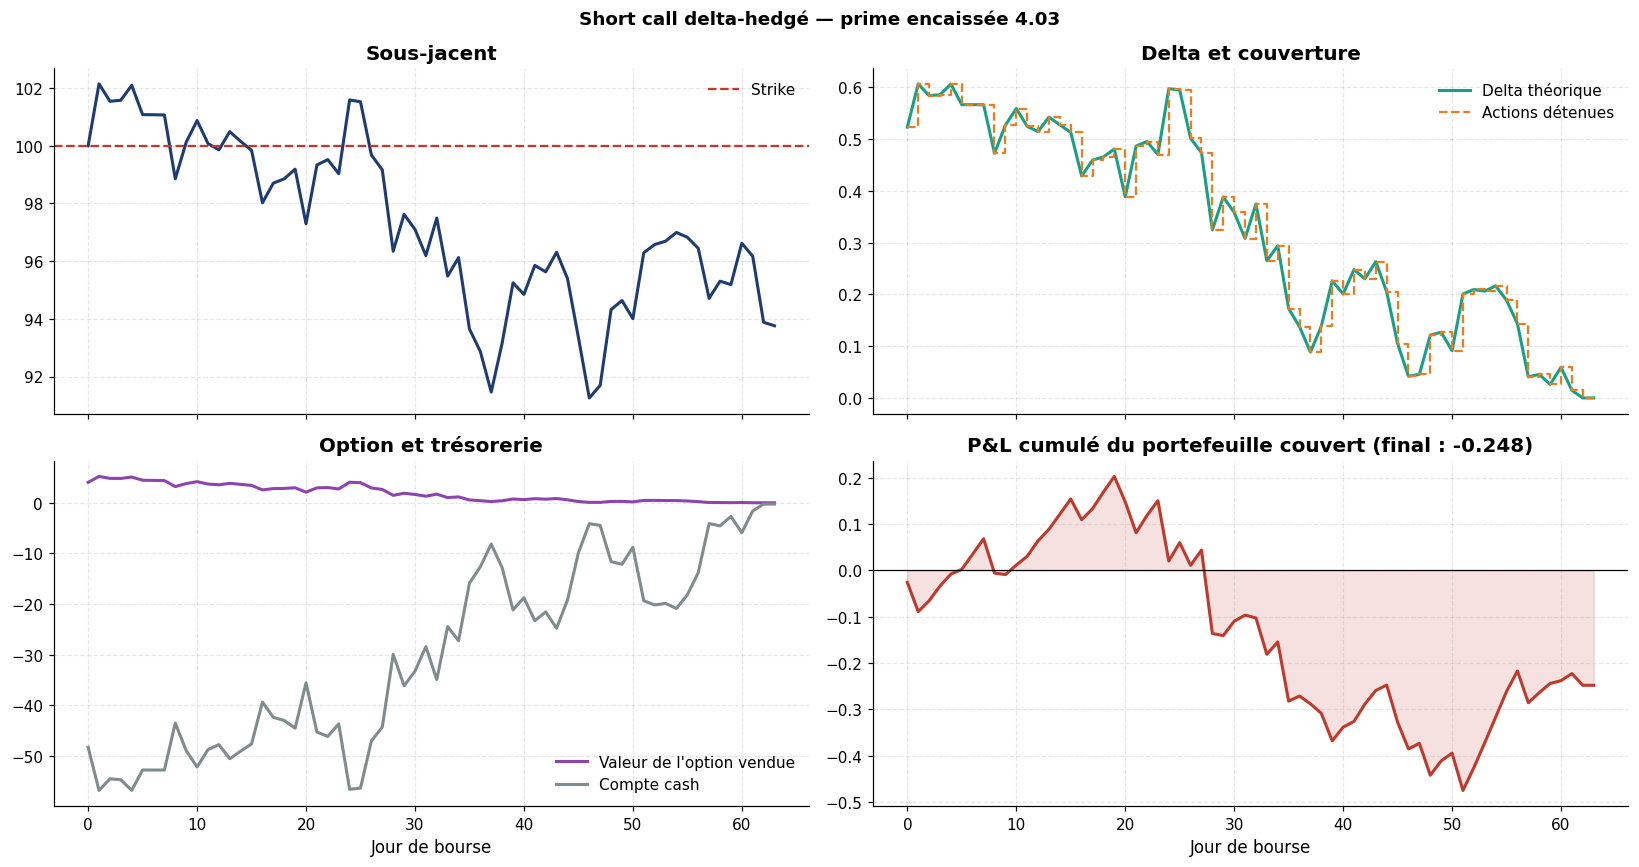

In [2]:
path = simulate_gbm_paths(100, 0.25, 0.20, 0.02, 0.015, 63, 1, seed=7)[:, 0]
one = delta_hedging(path, "call", 100.0, 0.25, 0.02, 0.20, "daily", 0.0005, q=0.015)
one.insert(0, "jour", range(len(one)))
display(one.iloc[[0, 1, 2, 30, 61, 62, 63]].round(4))

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
axes[0, 0].plot(one.jour, one.spot, color=PALETTE["navy"], lw=2); axes[0, 0].axhline(100, color=PALETTE["crimson"], ls="--", label="Strike")
axes[0, 0].set_title("Sous-jacent"); axes[0, 0].legend()
axes[0, 1].plot(one.jour, one.delta, color=PALETTE["teal"], lw=2, label="Delta théorique")
axes[0, 1].step(one.jour, one.stock_shares, where="post", color=PALETTE["orange"], lw=1.5, ls="--", label="Actions détenues")
axes[0, 1].set_title("Delta et couverture"); axes[0, 1].legend()
axes[1, 0].plot(one.jour, one.option_price, color=PALETTE["purple"], lw=2, label="Valeur de l'option vendue")
axes[1, 0].plot(one.jour, one.cash, color=PALETTE["grey"], lw=2, label="Compte cash")
axes[1, 0].set_title("Option et trésorerie"); axes[1, 0].legend(); axes[1, 0].set_xlabel("Jour de bourse")
axes[1, 1].plot(one.jour, one.cumulative_pnl, color=PALETTE["crimson"], lw=2); axes[1, 1].axhline(0, color="k", lw=0.8)
axes[1, 1].fill_between(one.jour, 0, one.cumulative_pnl, color=PALETTE["crimson"], alpha=0.15)
axes[1, 1].set_title(f"P&L cumulé du portefeuille couvert (final : {one.cumulative_pnl.iloc[-1]:.3f})"); axes[1, 1].set_xlabel("Jour de bourse")
fig.suptitle(f"Short call delta-hedgé — prime encaissée {one.option_price.iloc[0]:.2f}", fontweight="bold")
fig.tight_layout(); savefig(fig, "06_single_path_mechanics.png"); plt.show()

Le portefeuille démarre à −(frais initiaux) puis fluctue de quelques centimes autour de 0, alors que l'option vendue varie de plusieurs dollars : la couverture neutralise l'essentiel du risque directionnel. Ce qui reste est l'**erreur de couverture** liée au gamma.

## 2. Distribution du P&L de couverture (10 000 trajectoires)

Prime : 8.076 | P&L moyen : -0.0008 | écart-type : 0.4353 | théorie (Kamal-Derman) √(π/4)·Vega·σ/√N : 0.4354


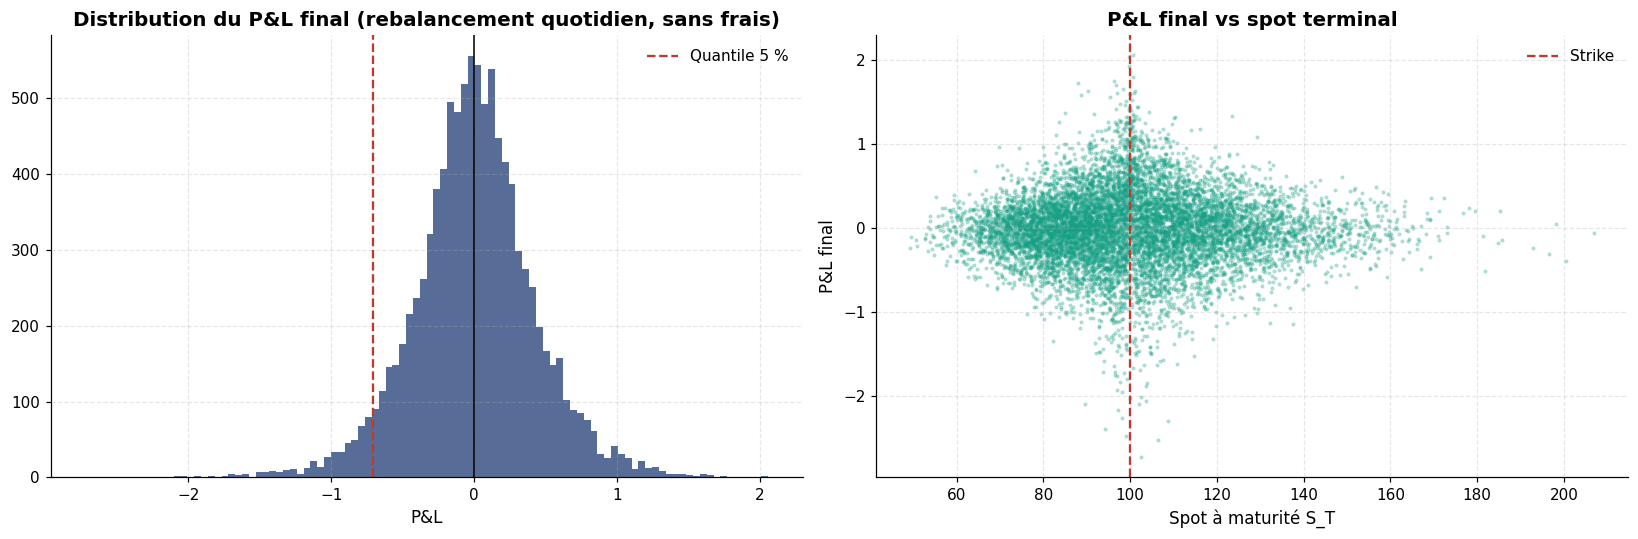

In [3]:
S0, K, T, r, q, sig = 100.0, 100.0, 1.0, 0.02, 0.015, 0.20
paths = simulate_gbm_paths(S0, T, sig, r, q, 252, 10_000, seed=42)
out = delta_hedging_vectorized(paths, "call", K, T, r, sig, 1, 0.0, q)
pnl, prem = out["pnl"], out["premium"][0]
theo_std = np.sqrt(np.pi / 4) * vega(S0, K, T, r, sig, "call", q) * sig / np.sqrt(252)
print(f"Prime : {prem:.3f} | P&L moyen : {pnl.mean():+.4f} | écart-type : {pnl.std():.4f} | "
      f"théorie (Kamal-Derman) √(π/4)·Vega·σ/√N : {theo_std:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].hist(pnl, bins=100, color=PALETTE["navy"], alpha=0.75)
axes[0].axvline(0, color="k", lw=1); axes[0].axvline(np.percentile(pnl, 5), color=PALETTE["crimson"], ls="--", label="Quantile 5 %")
axes[0].set_title("Distribution du P&L final (rebalancement quotidien, sans frais)"); axes[0].set_xlabel("P&L"); axes[0].legend()
axes[1].scatter(paths[-1], pnl, s=3, alpha=0.25, color=PALETTE["teal"])
axes[1].axvline(K, color=PALETTE["crimson"], ls="--", label="Strike")
axes[1].set_xlabel("Spot à maturité S_T"); axes[1].set_ylabel("P&L final"); axes[1].set_title("P&L final vs spot terminal"); axes[1].legend()
fig.tight_layout(); savefig(fig, "06_pnl_distribution.png"); plt.show()

- Le P&L est **centré sur zéro** : quand la vol réalisée égale la vol de pricing, la stratégie réplique l'option (il a fallu corriger la prise en compte du dividende sur les actions détenues pour obtenir ce résultat avec $q > 0$).
- Son écart-type (~0,44 pour une prime de ~8) est prédit presque exactement par la formule de Kamal-Derman $\sqrt{\pi/4}\,\text{Vega}\,\sigma/\sqrt{N}$ : l'erreur de couverture décroît en $1/\sqrt{N}$.
- La dispersion est maximale pour les trajectoires qui finissent **près du strike** : c'est là que le gamma est resté élevé longtemps.

## 3. Fréquence de rebalancement vs coûts de transaction

Trajectoires simulées avec 13 pas par jour de bourse (≈ un pas toutes les 30 minutes), call ATM 3 mois. On rebalance tous les $k$ pas : de toutes les 30 minutes à une fois par semaine. Frais proportionnels au montant échangé : 0, 1, 5 et 10 bp.

In [4]:
STEPS_PER_DAY, DAYS = 13, 63
T3 = DAYS / 252
fine = simulate_gbm_paths(S0, T3, sig, r, 0.0, STEPS_PER_DAY * DAYS, 5000, seed=1)
freqs = {"30 min": 1, "1 h": 2, "2 h": 4, "1 / jour": 13, "1 / 2 jours": 26, "1 / semaine": 65}
tcs = [0.0, 0.0001, 0.0005, 0.0010]
rows = []
for lab, k in freqs.items():
    base = delta_hedging_vectorized(fine, "call", K, T3, r, sig, k, 0.0, 0.0)
    unit = delta_hedging_vectorized(fine, "call", K, T3, r, sig, k, 1.0, 0.0)["tc"]   # volume échangé (frais = taux × volume)
    for tc in tcs:
        net = base["pnl"] - tc * unit * np.exp(0)  # frais payés au fil de l'eau (intérêts négligés ici)
        rows.append({"Fréquence": lab, "Rebal. / jour": STEPS_PER_DAY / k, "Frais (bp)": tc * 1e4,
                     "Erreur de couverture (écart-type)": base["pnl"].std(), "Frais moyens": tc * unit.mean(),
                     "P&L moyen net": net.mean(), "Écart-type net": net.std(),
                     "Coût total = écart-type + frais": base["pnl"].std() + tc * unit.mean()})
freq_tab = pd.DataFrame(rows)
prem3 = bs(S0, K, T3, r, sig, "call")
print(f"Prime du call 3 mois : {prem3:.3f}")
save_table(freq_tab, "06_rebalancing_frequency_study")
freq_tab.pivot(index="Fréquence", columns="Frais (bp)", values="Coût total = écart-type + frais").loc[list(freqs)]

Prime du call 3 mois : 4.232


Frais (bp),0.0000,1.0000,5.0000,10.0000
Fréquence,,,,
30 min,0.1219,0.2185,0.6051,1.0883
1 h,0.1716,0.2416,0.5217,0.8718
2 h,0.2400,0.2912,0.4961,0.7522
1 / jour,0.4341,0.4652,0.5896,0.7450
1 / 2 jours,0.6076,0.6315,0.7269,0.8462
1 / semaine,0.9286,0.9460,1.0158,1.1031


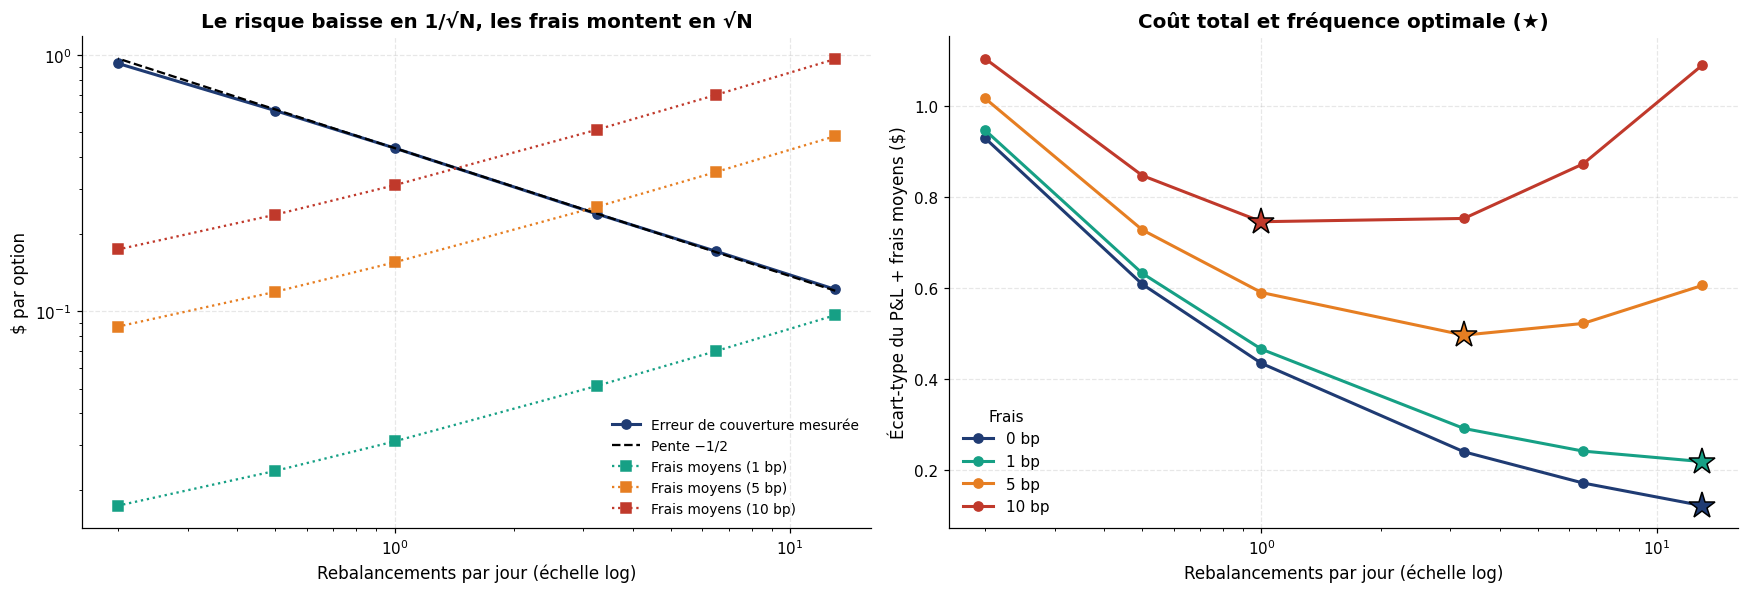

,Frais (bp),Fréquence,Coût total = écart-type + frais
0,0.0000,30 min,0.1219
1,1.0000,30 min,0.2185
10,5.0000,2 h,0.4961
15,10.0000,1 / jour,0.7450


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
f0 = freq_tab[freq_tab["Frais (bp)"] == 0]
axes[0].loglog(f0["Rebal. / jour"], f0["Erreur de couverture (écart-type)"], "o-", color=PALETTE["navy"], lw=2, label="Erreur de couverture mesurée")
x = f0["Rebal. / jour"].values
axes[0].loglog(x, f0["Erreur de couverture (écart-type)"].iloc[3] * np.sqrt(1 / x), "--", color="k", label="Pente −1/2")
for tc, c in zip(tcs[1:], [PALETTE["teal"], PALETTE["orange"], PALETTE["crimson"]]):
    ft = freq_tab[freq_tab["Frais (bp)"] == tc * 1e4]
    axes[0].loglog(ft["Rebal. / jour"], ft["Frais moyens"], "s:", color=c, label=f"Frais moyens ({tc*1e4:.0f} bp)")
axes[0].set_xlabel("Rebalancements par jour (échelle log)"); axes[0].set_ylabel("$ par option"); axes[0].legend(fontsize=9)
axes[0].set_title("Le risque baisse en 1/√N, les frais montent en √N")
for tc, c in zip(tcs, [PALETTE["navy"], PALETTE["teal"], PALETTE["orange"], PALETTE["crimson"]]):
    ft = freq_tab[freq_tab["Frais (bp)"] == tc * 1e4]
    axes[1].semilogx(ft["Rebal. / jour"], ft["Coût total = écart-type + frais"], "o-", color=c, lw=2, label=f"{tc*1e4:.0f} bp")
    i = ft["Coût total = écart-type + frais"].idxmin()
    axes[1].plot(ft.loc[i, "Rebal. / jour"], ft.loc[i, "Coût total = écart-type + frais"], "*", ms=18, color=c, mec="k")
axes[1].set_xlabel("Rebalancements par jour (échelle log)"); axes[1].set_ylabel("Écart-type du P&L + frais moyens ($)")
axes[1].set_title("Coût total et fréquence optimale (★)"); axes[1].legend(title="Frais")
fig.tight_layout(); savefig(fig, "06_rebalancing_tradeoff.png"); plt.show()

opt = freq_tab.loc[freq_tab.groupby("Frais (bp)")["Coût total = écart-type + frais"].idxmin(), ["Frais (bp)", "Fréquence", "Coût total = écart-type + frais"]]
save_table(opt, "06_optimal_frequency"); opt

**C'est le compromis central du market-making d'options.** Le risque résiduel décroît en $1/\sqrt{N}$ tandis que les frais cumulés croissent en $\sqrt{N}$ (la somme des $|\Delta\Delta|$ se comporte comme une variation quadratique). Le coût total $a/\sqrt N + b\sqrt N$ admet donc un minimum en $N^* = a/b$ :
- sans frais (et jusqu'à ~1 bp), la fréquence la plus élevée testée (toutes les 30 min) reste optimale : l'écart-type passe de 0,93 (hebdomadaire) à 0,12 ;
- à **5 bp**, l'optimum recule à **un rebalancement toutes les 2 heures** ; à **10 bp**, à **une fois par jour** — hedger toutes les 30 min coûterait alors 0,97 $ de frais par option, soit 23 % de la prime du call (4,23 $).

C'est l'intuition du modèle de **Leland (1985)** : les frais équivalent à une modification de la volatilité de pricing, et les desks utilisent en pratique des **bandes de tolérance** sur le delta plutôt qu'une fréquence fixe.

## 4. Rôle du gamma : ITM, ATM et OTM

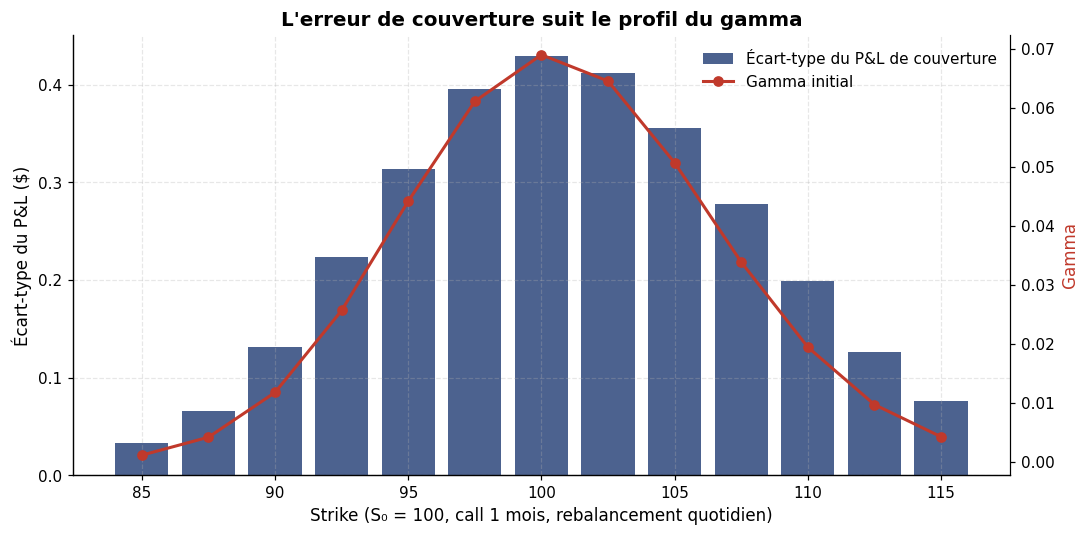

,Strike,Gamma initial,Prime,Écart-type P&L,Q1% P&L,Zone,Écart-type / prime (%)
2,90.0000,0.0117,10.2180,0.1318,-0.5049,ITM,1.2895
6,100.0000,0.0690,2.3853,0.4298,-1.1612,ATM,18.0192
10,110.0000,0.0194,0.1335,0.1994,-0.7667,OTM,149.4331


In [6]:
T1 = 21 / 252
p1 = simulate_gbm_paths(S0, T1, sig, r, 0.0, 21, 10_000, seed=3)
rows = []
for K_ in np.arange(85, 116, 2.5):
    o = delta_hedging_vectorized(p1, "call", K_, T1, r, sig, 1, 0.0)
    rows.append({"Strike": K_, "Gamma initial": gamma(S0, K_, T1, r, sig), "Prime": o["premium"][0],
                 "Écart-type P&L": o["pnl"].std(), "Q1% P&L": np.percentile(o["pnl"], 1)})
gam = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.bar(gam.Strike, gam["Écart-type P&L"], width=2, color=PALETTE["navy"], alpha=0.8, label="Écart-type du P&L de couverture")
ax.set_xlabel("Strike (S₀ = 100, call 1 mois, rebalancement quotidien)"); ax.set_ylabel("Écart-type du P&L ($)")
ax2 = ax.twinx(); ax2.plot(gam.Strike, gam["Gamma initial"], "o-", color=PALETTE["crimson"], lw=2, label="Gamma initial")
ax2.set_ylabel("Gamma", color=PALETTE["crimson"]); ax2.grid(False); ax2.spines["right"].set_visible(True)
ax.set_title("L'erreur de couverture suit le profil du gamma")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax.legend(h1 + h2, l1 + l2, loc="upper right")
savefig(fig, "06_gamma_moneyness.png"); plt.show()
sel = gam[gam.Strike.isin([90, 100, 110])].assign(Zone=["ITM", "ATM", "OTM"])
sel["Écart-type / prime (%)"] = 100 * sel["Écart-type P&L"] / sel.Prime
save_table(sel, "06_gamma_itm_atm_otm"); sel

Le risque de couverture est maximal **à la monnaie**, là où le gamma culmine : le delta y change le plus vite entre deux rebalancements. Rapporté à la prime, c'est l'option **OTM** qui est la plus risquée à couvrir (petite prime, gamma non négligeable) : un market-maker qui vend des options OTM courtes porte un risque de couverture très élevé relativement à ce qu'il encaisse. *(Expérience : un gamma élevé impose un rebalancement plus fréquent pour atteindre la même précision.)*

## 5. Erreur sur la volatilité : vol de couverture 20 % vs vol réalisée différente

Extension de l'expérience `experiences.py` du projet. Théorie : le vendeur gagne en moyenne ≈ $C(\sigma_{imp}) - C(\sigma_{réal})$.

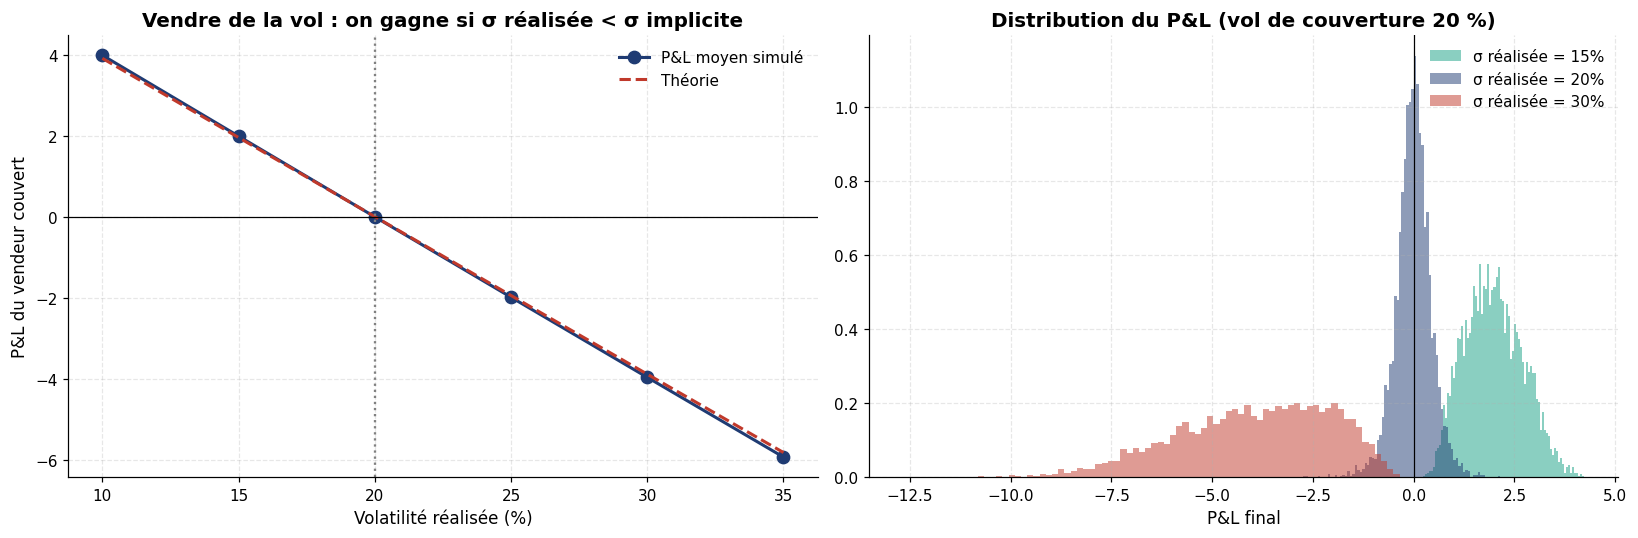

,Vol réalisée (%),P&L moyen,P&L médian,Écart-type,% P&L < 0,Théorie C(20 %) − C(σ réal.)
0,10.0000,3.9824,4.0242,1.0092,0.0000,3.9064
1,15.0000,1.9859,1.9549,0.7177,0.0000,1.9518
2,20.0000,-0.0057,0.0016,0.4413,49.8000,0.0000
3,25.0000,-1.9903,-1.8606,0.9971,100.0000,-1.9472
4,30.0000,-3.9670,-3.7696,1.9142,100.0000,-3.8885
5,35.0000,-5.9356,-5.6164,2.9624,100.0000,-5.8226


In [7]:
rows, dists = [], {}
for vol_real in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35]:
    pth = simulate_gbm_paths(S0, T, vol_real, r, q, 252, 5000, seed=42)
    o = delta_hedging_vectorized(pth, "call", K, T, r, 0.20, 1, 0.0, q)
    dists[vol_real] = o["pnl"]
    rows.append({"Vol réalisée (%)": 100 * vol_real, "P&L moyen": o["pnl"].mean(), "P&L médian": np.median(o["pnl"]),
                 "Écart-type": o["pnl"].std(), "% P&L < 0": 100 * (o["pnl"] < 0).mean(),
                 "Théorie C(20 %) − C(σ réal.)": bs(S0, K, T, r, 0.20, "call", q) - bs(S0, K, T, r, vol_real, "call", q)})
volmis = pd.DataFrame(rows); save_table(volmis, "06_vol_misspecification")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(volmis["Vol réalisée (%)"], volmis["P&L moyen"], "o-", color=PALETTE["navy"], lw=2, ms=8, label="P&L moyen simulé")
axes[0].plot(volmis["Vol réalisée (%)"], volmis["Théorie C(20 %) − C(σ réal.)"], "--", color=PALETTE["crimson"], lw=2, label="Théorie")
axes[0].axhline(0, color="k", lw=0.8); axes[0].axvline(20, color="grey", ls=":")
axes[0].set_xlabel("Volatilité réalisée (%)"); axes[0].set_ylabel("P&L du vendeur couvert"); axes[0].legend()
axes[0].set_title("Vendre de la vol : on gagne si σ réalisée < σ implicite")
for v, c in zip([0.15, 0.20, 0.30], [PALETTE["teal"], PALETTE["navy"], PALETTE["crimson"]]):
    axes[1].hist(dists[v], bins=80, alpha=0.5, color=c, label=f"σ réalisée = {v:.0%}", density=True)
axes[1].axvline(0, color="k", lw=0.8); axes[1].set_xlabel("P&L final"); axes[1].legend(); axes[1].set_title("Distribution du P&L (vol de couverture 20 %)")
fig.tight_layout(); savefig(fig, "06_vol_misspecification.png"); plt.show()
volmis

Le delta-hedging **ne supprime pas l'exposition à la volatilité** : il transforme une position directionnelle en une position sur l'écart entre volatilité implicite et volatilité réalisée. Le P&L simulé suit presque exactement la différence de prix Black-Scholes. C'est le mécanisme qui relie le hedging au **volatility risk premium** (notebook 07).

## 6. Risque de modèle : le monde est Heston, on couvre avec Black-Scholes

Sous-jacent simulé avec les paramètres Heston calibrés au notebook 05. Le trader vend le call ATM 3 mois à son **juste prix Heston** et le couvre avec le delta Black-Scholes à la vol implicite de ce prix. Comparaison avec un monde Black-Scholes de même vol.

Paramètres Heston (2022-08-01) : v0=0.0423, κ=9.36, θ=0.0720, ξ=2.12, ρ=-0.60
Prix Heston du call ATM 3 mois : 4.465 -> vol implicite BS 21.17%


,Moyenne,Écart-type,Q1%,Q5%,Médiane,Q95%,CVaR 5%,% P&L < 0,Écart-type / prime (%)
Monde Black-Scholes (σ constante),0.0014,0.4594,-1.2249,-0.7539,0.0067,0.7429,-1.0506,49.3050,10.2870
Monde Heston (paramètres calibrés),-0.0160,2.2152,-7.8876,-4.1445,0.4310,2.5107,-6.5666,41.0850,49.6091


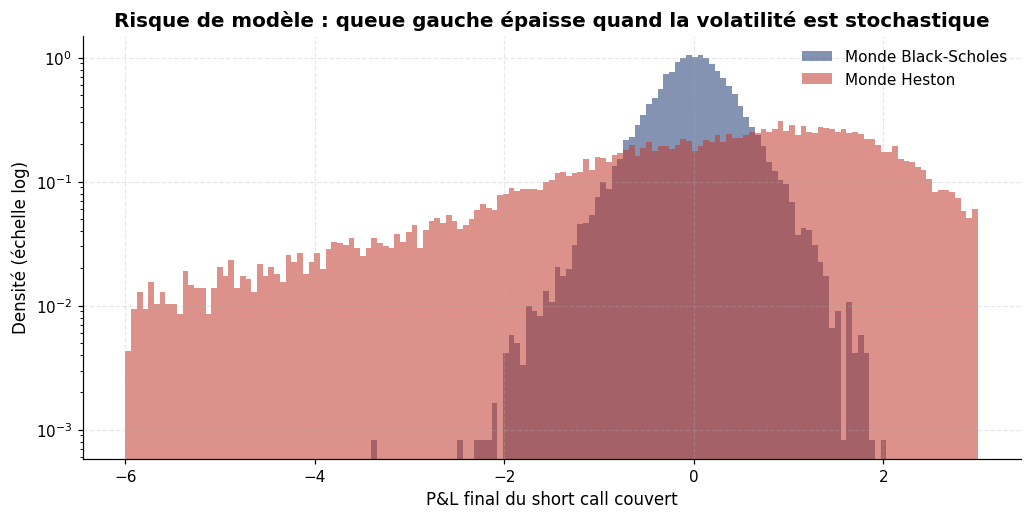

In [8]:
hp = json.load(open(RES_DIR / "heston_params.json"))
v0, kappa, theta, xi, rho = (hp[k] for k in ["v0", "kappa", "theta", "xi", "rho"])
n_steps = 63
price_h = heston_call_price(S0, K, T3, r, v0, kappa, theta, xi, rho)
iv_h = implied_volatility(price_h, S0, K, T3, r, "call")
Sh, _ = simulate_heston_paths(S0, v0, r, kappa, theta, xi, rho, T3, n_steps, 20_000, seed=5)
Sg = simulate_gbm_paths(S0, T3, iv_h, r, 0.0, n_steps, 20_000, seed=5)
pnl_h = delta_hedging_vectorized(Sh, "call", K, T3, r, iv_h, 1, 0.0)["pnl"]
pnl_g = delta_hedging_vectorized(Sg, "call", K, T3, r, iv_h, 1, 0.0)["pnl"]
mr = pd.DataFrame({"Monde Black-Scholes (σ constante)": stats(pnl_g, price_h), "Monde Heston (paramètres calibrés)": stats(pnl_h, price_h)}).T
print(f"Paramètres Heston ({hp['date']}) : v0={v0:.4f}, κ={kappa:.2f}, θ={theta:.4f}, ξ={xi:.2f}, ρ={rho:.2f}")
print(f"Prix Heston du call ATM 3 mois : {price_h:.3f} -> vol implicite BS {iv_h:.2%}")
save_table(mr.reset_index(names="Monde"), "06_model_risk_heston"); display(mr)
fig, ax = plt.subplots(figsize=(11, 5))
bins = np.linspace(-6, 3, 150)
ax.hist(pnl_g, bins=bins, alpha=0.55, density=True, color=PALETTE["navy"], label="Monde Black-Scholes")
ax.hist(pnl_h, bins=bins, alpha=0.55, density=True, color=PALETTE["crimson"], label="Monde Heston")
ax.set_yscale("log"); ax.set_xlabel("P&L final du short call couvert"); ax.set_ylabel("Densité (échelle log)")
ax.set_title("Risque de modèle : queue gauche épaisse quand la volatilité est stochastique"); ax.legend()
savefig(fig, "06_model_risk_heston.png"); plt.show()

À prix juste identique, la couverture Black-Scholes laisse un risque bien plus grand dans un monde à volatilité stochastique : le delta ne couvre pas le **risque de vega** (la vol elle-même bouge) ni la corrélation spot-vol. La distribution devient asymétrique avec une **queue gauche épaisse** — les scénarios de hausse de vol coûtent cher au vendeur. En pratique, un desk couvre aussi la vega (avec d'autres options) et utilise des deltas ajustés du skew (*smile-adjusted delta*).

## 7. Stress tests

### 7.1 Gap risk : choc instantané sur le spot, sans possibilité de rebalancer

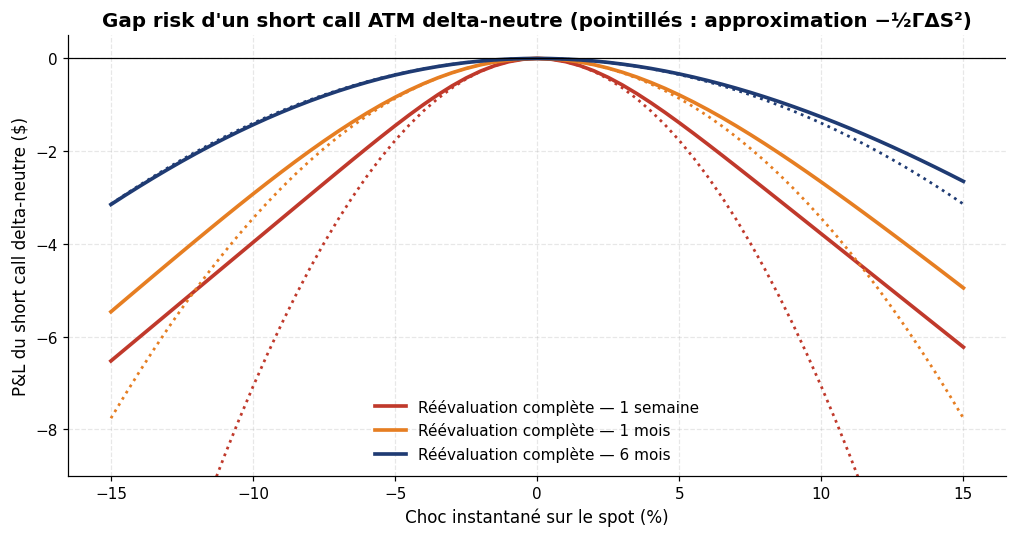

In [9]:
shocks = np.linspace(-0.15, 0.15, 61)
fig, ax = plt.subplots(figsize=(11, 5.2))
for Tm, c, lab in [(5/252, PALETTE["crimson"], "1 semaine"), (21/252, PALETTE["orange"], "1 mois"), (0.5, PALETTE["navy"], "6 mois")]:
    c0, d0, g0 = bs(S0, K, Tm, r, sig, "call"), delta(S0, K, Tm, r, sig, "call"), gamma(S0, K, Tm, r, sig, "call")
    exact = [-(bs(S0 * (1 + x), K, Tm, r, sig, "call") - c0 - d0 * S0 * x) for x in shocks]
    ax.plot(shocks * 100, exact, lw=2.4, color=c, label=f"Réévaluation complète — {lab}")
    ax.plot(shocks * 100, -0.5 * g0 * (S0 * shocks)**2, ":", lw=1.8, color=c)
ax.axhline(0, color="k", lw=0.8); ax.set_ylim(-9, 0.5)
ax.set_xlabel("Choc instantané sur le spot (%)"); ax.set_ylabel("P&L du short call delta-neutre ($)")
ax.set_title("Gap risk d'un short call ATM delta-neutre (pointillés : approximation −½ΓΔS²)"); ax.legend()
savefig(fig, "06_gap_risk.png"); plt.show()

Un portefeuille delta-neutre **short gamma** perd dans les deux directions : la perte est quadratique ($-\tfrac12\Gamma\Delta S^2$) et d'autant plus violente que l'option est courte. Au-delà de quelques pourcents, l'approximation gamma devient insuffisante et il faut réévaluer complètement (convexité du gamma lui-même).

### 7.2 Matrice de scénarios spot × volatilité (short call ATM 3 mois delta-neutre)

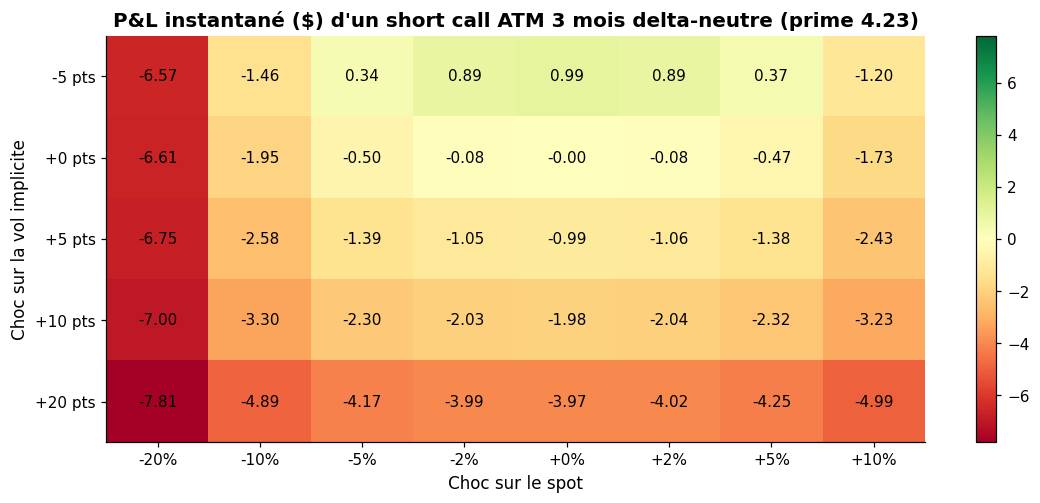

In [10]:
spot_sh = [-0.20, -0.10, -0.05, -0.02, 0.0, 0.02, 0.05, 0.10]
vol_sh = [-0.05, 0.0, 0.05, 0.10, 0.20]
c0, d0 = bs(S0, K, T3, r, sig, "call"), delta(S0, K, T3, r, sig, "call")
mat = pd.DataFrame([[-(bs(S0 * (1 + x), K, T3, r, sig + v, "call") - c0 - d0 * S0 * x) for x in spot_sh] for v in vol_sh],
                   index=[f"{v*100:+.0f} pts" for v in vol_sh], columns=[f"{x:+.0%}" for x in spot_sh])
fig, ax = plt.subplots(figsize=(12, 4.8))
lim = np.abs(mat.values).max()
im = ax.imshow(mat.values, cmap="RdYlGn", vmin=-lim, vmax=lim, aspect="auto")
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat.values[i, j]:.2f}", ha="center", va="center", fontsize=10)
ax.set_xticks(range(len(spot_sh)), mat.columns); ax.set_yticks(range(len(vol_sh)), mat.index); ax.grid(False)
ax.set_xlabel("Choc sur le spot"); ax.set_ylabel("Choc sur la vol implicite")
ax.set_title(f"P&L instantané ($) d'un short call ATM 3 mois delta-neutre (prime {c0:.2f})")
fig.colorbar(im, ax=ax); savefig(fig, "06_stress_matrix.png"); plt.show()
save_table(mat.reset_index(names="Choc vol"), "06_stress_matrix", floatfmt=".2f")

Le scénario le plus dangereux pour un vendeur d'options est la combinaison **krach + hausse de vol** (coin inférieur gauche) — précisément la dynamique observée sur les indices (corrélation spot-vol négative, $\rho < 0$ dans Heston). Une baisse de 20 % accompagnée de +20 points de vol coûte **7,8 $, soit 1,8 fois la prime encaissée** (4,2 $). Pour de petits mouvements de spot, c'est le choc de vol qui domine (vega) ; pour les gros mouvements, c'est le gamma.

## 8. Backtest sur données réelles SPY 2022

### 8.1 Un call ATM vendu le 3 janvier 2022, échéance 30 décembre 2022

Spot réel quotidien, IV quotidienne du contrat (fournisseur), 1 bp de frais, r = 2 %, q = 1,5 %. Comparaison : couverture avec l'**IV du jour** (mark-to-market), avec l'**IV initiale figée**, et **sans couverture**.

In [11]:
R_BT, Q_BT, TC_BT = 0.02, 0.015, 0.0001
chain_all = get_option_chain(quote_date="all")
chain_all["quote_date"] = pd.to_datetime(chain_all.quote_date); chain_all["expiration"] = pd.to_datetime(chain_all.expiration)
spot_hist = get_underlying_history()

def backtest_contract(entry, expiration, strike, opt="call", iv_mode="daily", tc=TC_BT):
    dates = spot_hist.loc[entry:expiration].index
    c = chain_all[(chain_all.expiration == expiration) & (chain_all.strike == strike) & (chain_all.option_type == opt)].set_index("quote_date")
    iv = c.source_iv.reindex(dates).where(lambda x: x.between(0.03, 1.5)).ffill().bfill()
    if iv_mode == "constant":
        iv[:] = iv.iloc[0]
    tau = ((expiration - dates).days / 365).values
    res = historical_backtest(spot_hist.loc[dates].values, iv.values, dates, strike, tau[0], R_BT, opt, tc, Q_BT, tau_history=tau)
    mid0 = ((c.bid + c.ask) / 2).get(dates[0], np.nan)
    return res, mid0

entry, expiry = pd.Timestamp("2022-01-03"), pd.Timestamp("2022-12-30")
K_bt = 478.0
bt_daily, mid0 = backtest_contract(entry, expiry, K_bt)
bt_const, _ = backtest_contract(entry, expiry, K_bt, iv_mode="constant")
prem = bt_daily.option_price.iloc[0]
tau_path = bt_daily.time_to_maturity.values
unhedged = prem * np.exp(R_BT * (tau_path[0] - tau_path)) - bt_daily.option_price.values
rv = np.log(bt_daily.spot).diff().std() * np.sqrt(252)
print(f"Prime modèle {prem:.2f} (mid de marché {mid0:.2f}) | IV initiale {bt_daily.vol_implicite.iloc[0]:.2%} | vol réalisée 2022 : {rv:.2%}")
summary = pd.DataFrame({"Stratégie": ["Couverture (IV du jour)", "Couverture (IV initiale figée)", "Sans couverture"],
                        "P&L final ($)": [bt_daily.cumulative_pnl.iloc[-1], bt_const.cumulative_pnl.iloc[-1], unhedged[-1]],
                        "Pire P&L en cours de route ($)": [bt_daily.cumulative_pnl.min(), bt_const.cumulative_pnl.min(), unhedged.min()],
                        "Frais totaux ($)": [bt_daily.transaction_costs.sum(), bt_const.transaction_costs.sum(), 0.0]})
summary["P&L final / prime (%)"] = 100 * summary["P&L final ($)"] / prem
save_table(summary, "06_backtest_annual_call", floatfmt=".2f"); summary

Prime modèle 36.55 (mid de marché 35.48) | IV initiale 19.08% | vol réalisée 2022 : 24.34%


,Stratégie,P&L final ($),Pire P&L en cours de route ($),Frais totaux ($),P&L final / prime (%)
0,Couverture (IV du jour),-2.8867,-3.0897,0.1722,-7.8969
1,Couverture (IV initiale figée),-5.0563,-5.0568,0.1766,-13.8321
2,Sans couverture,37.2848,0.0000,0.0000,101.9978


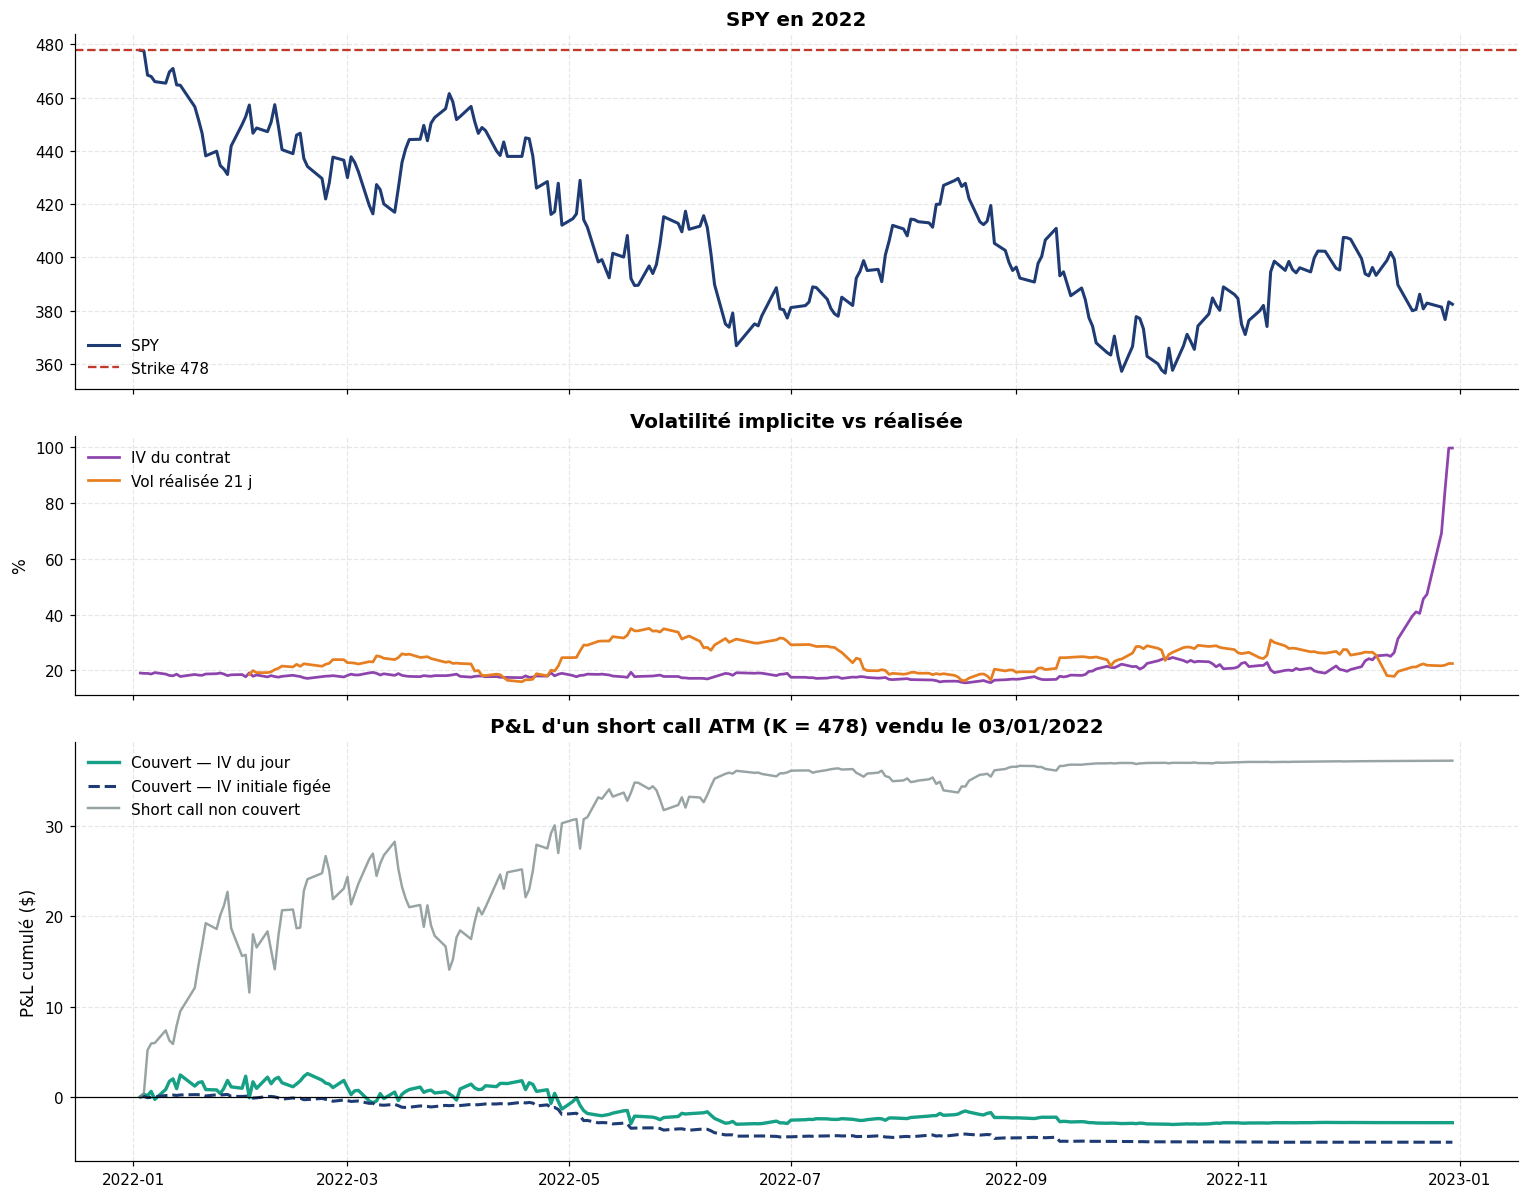

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True, gridspec_kw={"height_ratios": [1.1, 0.8, 1.3]})
axes[0].plot(bt_daily.date, bt_daily.spot, color=PALETTE["navy"], lw=2, label="SPY"); axes[0].axhline(K_bt, color=PALETTE["crimson"], ls="--", label=f"Strike {K_bt:.0f}")
axes[0].set_title("SPY en 2022"); axes[0].legend()
axes[1].plot(bt_daily.date, bt_daily.vol_implicite * 100, color=PALETTE["purple"], lw=1.8, label="IV du contrat")
axes[1].plot(bt_daily.date, np.log(bt_daily.spot).diff().rolling(21).std() * np.sqrt(252) * 100, color=PALETTE["orange"], lw=1.8, label="Vol réalisée 21 j")
axes[1].set_ylabel("%"); axes[1].legend(); axes[1].set_title("Volatilité implicite vs réalisée")
axes[2].plot(bt_daily.date, bt_daily.cumulative_pnl, color=PALETTE["teal"], lw=2.2, label="Couvert — IV du jour")
axes[2].plot(bt_const.date, bt_const.cumulative_pnl, color=PALETTE["navy"], lw=2, ls="--", label="Couvert — IV initiale figée")
axes[2].plot(bt_daily.date, unhedged, color=PALETTE["grey"], lw=1.6, alpha=0.8, label="Short call non couvert")
axes[2].axhline(0, color="k", lw=0.8); axes[2].set_ylabel("P&L cumulé ($)"); axes[2].legend(); axes[2].set_title("P&L d'un short call ATM (K = 478) vendu le 03/01/2022")
fig.tight_layout(); savefig(fig, "06_backtest_annual_call.png"); plt.show()

**Lecture.** Le call vendu en janvier (IV 19,1 %) a vu le marché baisser de 20 % avec une vol réalisée de 24,3 % : non couvert, le vendeur **gagne toute la prime** (le call finit très OTM) — mais c'est un pari baissier gagnant, pas un gain de trading de volatilité. Couvert, le vendeur **perd 7,9 % de la prime** : la couverture a supprimé l'exposition directionnelle et laissé l'exposition à $\sigma_{réal} > \sigma_{imp}$. La perte reste limitée car le gamma s'est effondré quand l'option est devenue OTM (le P&L de gamma est pondéré par $\Gamma S^2$). Couvrir avec l'IV **initiale figée** fait perdre davantage (−13,8 %) : l'IV du marché a monté dans l'année, et un delta calculé à 19 % de vol était trop faible pour un call qui se rapprochait de la monnaie.

### 8.2 Stratégie glissante : vendre chaque mois un call ATM ~30 jours et le delta-hedger

In [13]:
trades = []
for m in range(1, 13):
    e = spot_hist[spot_hist.index.month == m].index[0]
    exps = pd.DatetimeIndex(chain_all.loc[chain_all.quote_date == e, "expiration"].unique())
    x = exps[np.argmin(np.abs((exps - (e + pd.Timedelta(days=30))).days))]
    if x > spot_hist.index[-1]:
        continue
    ks = chain_all.loc[(chain_all.quote_date == e) & (chain_all.expiration == x), "strike"].unique()
    k_ = ks[np.argmin(np.abs(ks - spot_hist[e]))]
    res_, _ = backtest_contract(e, x, k_)
    rets = np.log(res_.spot).diff().dropna()
    trades.append({"Entrée": e.date(), "Échéance": x.date(), "Strike": k_, "Spot entrée": res_.spot.iloc[0], "Spot échéance": res_.spot.iloc[-1],
                   "IV entrée (%)": 100 * res_.vol_implicite.iloc[0], "Vol réalisée (%)": 100 * rets.std() * np.sqrt(252),
                   "Prime": res_.option_price.iloc[0], "P&L couvert": res_.cumulative_pnl.iloc[-1],
                   "P&L non couvert": res_.option_price.iloc[0] * np.exp(R_BT * res_.time_to_maturity.iloc[0]) - max(res_.spot.iloc[-1] - k_, 0)})
tr = pd.DataFrame(trades)
tr["IV − RV (pts)"] = tr["IV entrée (%)"] - tr["Vol réalisée (%)"]
tr["P&L couvert / prime (%)"] = 100 * tr["P&L couvert"] / tr["Prime"]
save_table(tr, "06_backtest_monthly_calls", floatfmt=".2f")
tr

,Entrée,Échéance,Strike,Spot entrée,Spot échéance,IV entrée (%),Vol réalisée (%),Prime,P&L couvert,P&L non couvert,IV − RV (pts),P&L couvert / prime (%)
0,2022-01-03,2022-02-02,478.0000,477.7700,457.2300,12.0870,18.5678,6.5798,-1.5812,6.5907,-6.4808,-24.0310
1,2022-02-01,2022-03-02,453.0000,452.8800,437.7900,17.9300,23.1713,9.1487,-1.7806,9.1632,-5.2413,-19.4633
2,2022-03-01,2022-03-31,430.0000,429.9900,451.7700,27.0220,22.7738,13.3504,1.5936,-8.3977,4.2482,11.9371
3,2022-04-01,2022-05-02,453.0000,452.9200,414.5500,15.8630,25.1211,8.3970,-0.8144,8.4112,-9.2581,-9.6991
4,2022-05-02,2022-06-01,415.0000,414.5500,409.6400,27.1150,31.9632,12.7023,-2.0322,12.7232,-4.8482,-15.9983
5,2022-06-01,2022-07-01,410.0000,409.6400,381.2000,23.5880,30.7296,10.9429,-1.9422,10.9609,-7.1416,-17.7481
6,2022-07-01,2022-08-01,381.0000,381.2000,410.7200,23.7630,18.9938,10.6928,0.7986,-19.0090,4.7692,7.4690
7,2022-08-01,2022-08-31,411.0000,410.7200,395.1300,19.7300,19.7608,9.2014,-1.2369,9.2166,-0.0308,-13.4426
8,2022-09-01,2022-09-30,396.0000,396.3900,357.2700,23.0840,24.5518,10.5440,-1.1685,10.5608,-1.4678,-11.0817
9,2022-10-03,2022-11-02,367.0000,366.6200,374.8600,25.8970,27.4102,10.7324,-0.7956,2.8901,-1.5132,-7.4132


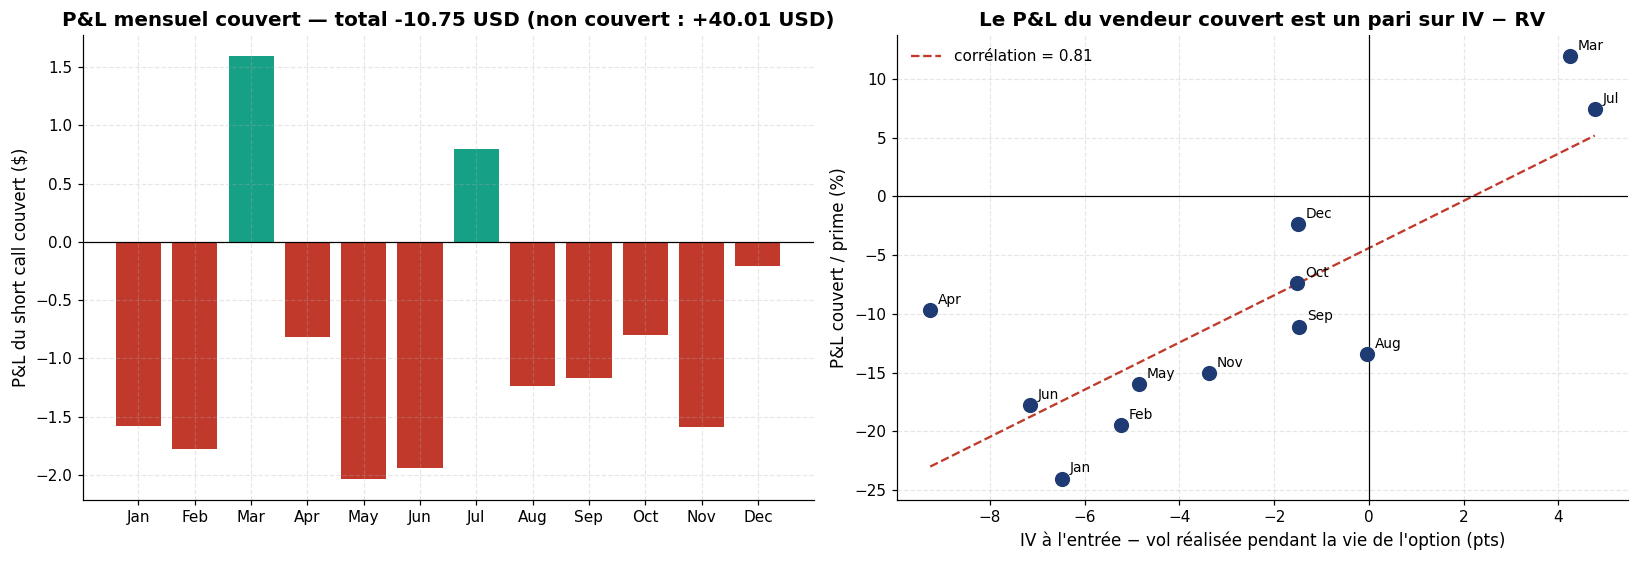

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
cols = [PALETTE["teal"] if v > 0 else PALETTE["crimson"] for v in tr["P&L couvert"]]
axes[0].bar(pd.to_datetime(tr["Entrée"]).dt.strftime("%b"), tr["P&L couvert"], color=cols)
axes[0].axhline(0, color="k", lw=0.8); axes[0].set_ylabel("P&L du short call couvert ($)")
axes[0].set_title(f"P&L mensuel couvert — total {tr['P&L couvert'].sum():+.2f} USD (non couvert : {tr['P&L non couvert'].sum():+.2f} USD)")
axes[1].scatter(tr["IV − RV (pts)"], tr["P&L couvert / prime (%)"], s=80, color=PALETTE["navy"], zorder=3)
for _, rw in tr.iterrows():
    axes[1].annotate(pd.Timestamp(rw["Entrée"]).strftime("%b"), (rw["IV − RV (pts)"], rw["P&L couvert / prime (%)"]), xytext=(5, 4), textcoords="offset points", fontsize=9)
b = np.polyfit(tr["IV − RV (pts)"], tr["P&L couvert / prime (%)"], 1); xx = np.linspace(tr["IV − RV (pts)"].min(), tr["IV − RV (pts)"].max(), 10)
axes[1].plot(xx, np.polyval(b, xx), "--", color=PALETTE["crimson"], label=f"corrélation = {np.corrcoef(tr['IV − RV (pts)'], tr['P&L couvert / prime (%)'])[0,1]:.2f}")
axes[1].axhline(0, color="k", lw=0.8); axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_xlabel("IV à l'entrée − vol réalisée pendant la vie de l'option (pts)"); axes[1].set_ylabel("P&L couvert / prime (%)")
axes[1].set_title("Le P&L du vendeur couvert est un pari sur IV − RV"); axes[1].legend()
fig.tight_layout(); savefig(fig, "06_backtest_monthly_calls.png"); plt.show()

**Lecture.** 10 mois sur 12, l'IV à l'entrée était **inférieure** à la vol réalisée ensuite, et le vendeur couvert a perdu. Les deux seuls gains (mars, juillet) suivent des pics de vol (invasion de l'Ukraine, plus bas de juin) : l'IV était alors élevée et le marché s'est calmé. La relation est quasi linéaire (corrélation 0,81), comme le prévoit $\text{P\&L} \approx \tfrac12\int \Gamma S^2(\sigma_{imp}^2 - \sigma_{réal}^2)\,dt$. À $IV = RV$ (août), le P&L reste légèrement négatif (~−4 % de la prime en moyenne selon la régression) : frais, rebalancement quotidien seulement, et vol réalisée mesurée *close-to-close* alors que l'IV intègre aussi les mouvements intra-journaliers et les sauts.

## Conclusions

1. **Le delta-hedging fonctionne** : en monde Black-Scholes avec la bonne vol, le P&L est centré sur zéro et son écart-type suit la loi théorique $\sqrt{\pi/4}\,\text{Vega}\,\sigma/\sqrt N$.
2. **Fréquence vs coûts** : le risque résiduel décroît en $1/\sqrt N$, les frais croissent en $\sqrt N$ ; il existe une fréquence optimale qui recule quand les frais augmentent (quelques rebalancements par jour à 1 bp, ~quotidien ou moins au-delà).
3. **Gamma** : l'erreur de couverture est maximale ATM et sur les maturités courtes ; relativement à la prime, les options OTM courtes sont les plus risquées.
4. **Volatilité** : la couverture delta laisse une exposition pure à $\sigma_{imp}-\sigma_{réal}$ ; le P&L moyen suit la théorie $C(\sigma_{imp}) - C(\sigma_{réal})$.
5. **Risque de modèle** : si la vol est stochastique (Heston calibré), la même stratégie a une queue gauche bien plus épaisse. Il faut couvrir aussi la vega.
6. **Stress** : un short gamma perd dans les deux sens sur un gap ; le pire scénario est krach + hausse de vol.
7. **Données réelles 2022** (année baissière et volatile) : la couverture supprime le risque directionnel, **pas le risque de volatilité**. Le call annuel couvert perd 7,9 % de sa prime (vol réalisée 24,3 % > IV initiale 19,1 %). Sur la stratégie glissante, **10 trades sur 12 perdent** (−10,75 $ cumulés) et le P&L couvert est corrélé à **0,81** avec $IV - RV$ : on retrouve empiriquement la formule du P&L de gamma. Le même short call *non couvert* gagne +40 $, mais uniquement parce que le marché a baissé : un risque directionnel qu'un market-maker ne veut pas porter.